# Lesson 2: Linear Regression

Predicting continuous values with linear models.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes, fetch_california_housing

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Simple Linear Regression

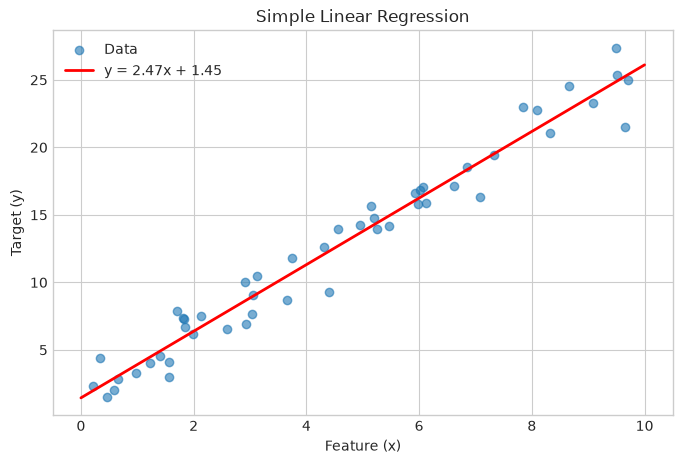

Intercept: 1.4450
Coefficient: 2.4665
R²: 0.964


In [2]:
X = np.random.rand(50, 1) * 10
y = 2.5 * X.ravel() + 1.3 + np.random.normal(0, 1.5, 50)

model = LinearRegression()
model.fit(X, y)

X_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(X_line, y_line, 'r-', linewidth=2,
         label=f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
plt.xlabel('Feature (x)')
plt.ylabel('Target (y)')
plt.legend()
plt.title('Simple Linear Regression')
plt.show()

print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"R²: {model.score(X, y):.3f}")

## 2. Multiple Linear Regression with Diabetes Dataset

In [3]:
data = load_diabetes()
X, y = pd.DataFrame(data.data, columns=data.feature_names), data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

coef_df = pd.DataFrame({
    'feature': data.feature_names,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Coefficients:")
print(coef_df.to_string(index=False))
print(f"\nMSE:  {mean_squared_error(y_test, y_pred):.1f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.1f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

Coefficients:
feature  coefficient
     s1  -931.488846
     s5   736.198859
    bmi   542.428759
     s2   518.062277
     bp   347.703844
     s4   275.317902
    sex  -241.964362
     s3   163.419983
     s6    48.670657
    age    37.904021

MSE:  2900.2
RMSE: 53.9
R²:   0.453


## 3. Coefficient Interpretation

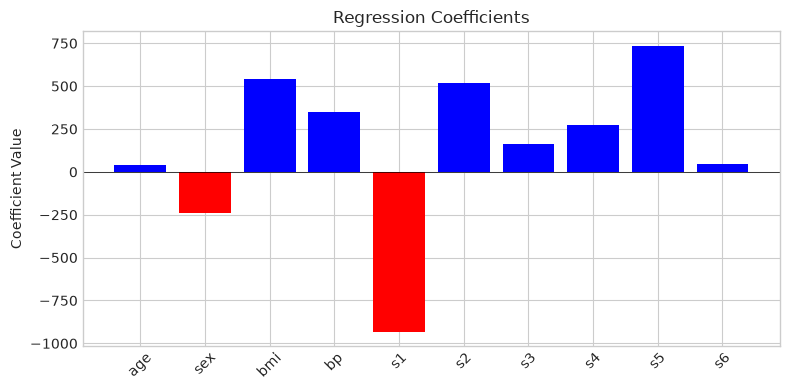

In [4]:
plt.figure(figsize=(8, 4))
colors = ['red' if c < 0 else 'blue' for c in model.coef_]
plt.bar(data.feature_names, model.coef_, color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Regression Coefficients')
plt.xticks(rotation=45)
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()

**Interpretation:** A one-unit increase in `bmi` is associated with a change of approximately 600 in the disease progression score, holding other features constant.

## 4. OLS from Scratch

In [5]:
def ols_scratch(X, y):
    X_with_intercept = np.c_[np.ones(X.shape[0]), X]
    beta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y
    intercept = beta[0]
    coefficients = beta[1:]
    y_pred = X_with_intercept @ beta
    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)
    return coefficients, intercept, r2

coef_scratch, int_scratch, r2_scratch = ols_scratch(X_train.values, y_train)
print(f"Scratch - R²: {r2_scratch:.3f}")
print(f"Sklearn - R²: {model.score(X_test, y_test):.3f}")
print(f"Coefficients match: {np.allclose(coef_scratch, model.coef_, atol=1e-10)}")

Scratch - R²: 0.528
Sklearn - R²: 0.453
Coefficients match: True


## 5. Gradient Descent Intuition

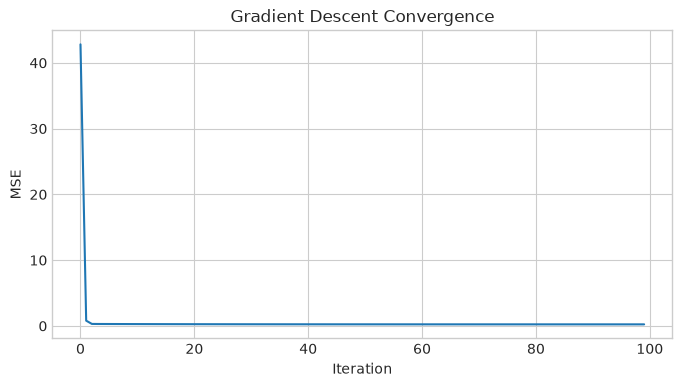

Gradient descent: y = 1.94x + 1.11
Sklearn:          y = 1.92x + 1.16


In [6]:
from sklearn.preprocessing import StandardScaler

# Simple 1D case for visualization
X_gd = np.random.rand(30, 1) * 5
y_gd = 2 * X_gd.ravel() + 1 + np.random.normal(0, 0.5, 30)

m, b = 0.0, 0.0
alpha = 0.05
n = len(X_gd)
history = []

for _ in range(100):
    y_pred_gd = m * X_gd.ravel() + b
    dm = (-2/n) * np.sum(X_gd.ravel() * (y_gd - y_pred_gd))
    db = (-2/n) * np.sum(y_gd - y_pred_gd)
    m -= alpha * dm
    b -= alpha * db
    history.append(mean_squared_error(y_gd, y_pred_gd))

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Convergence')
plt.show()

print(f"Gradient descent: y = {m:.2f}x + {b:.2f}")
print(f"Sklearn:          y = {LinearRegression().fit(X_gd, y_gd).coef_[0]:.2f}x + {LinearRegression().fit(X_gd, y_gd).intercept_:.2f}")

## 6. Biotechnology Example: Protein Solubility

In [7]:
n = 200
bio_data = pd.DataFrame({
    'mol_weight': np.random.normal(50000, 10000, n),
    'hydrophobicity': np.random.uniform(-2, 2, n),
    'charge': np.random.normal(0, 5, n),
    'helix_frac': np.random.uniform(0, 1, n),
})
bio_data['solubility'] = (
    0.5 - 0.3 * bio_data['hydrophobicity']
    + 0.1 * bio_data['charge']
    + 0.2 * bio_data['helix_frac']
    + np.random.normal(0, 0.1, n)
)

X_bio = bio_data.drop('solubility', axis=1)
y_bio = bio_data['solubility']
model_bio = LinearRegression().fit(X_bio, y_bio)

for col, coef in zip(X_bio.columns, model_bio.coef_):
    print(f"{col}: {coef:.4f}")
print(f"R²: {model_bio.score(X_bio, y_bio):.3f}")

mol_weight: -0.0000
hydrophobicity: -0.2969
charge: 0.1007
helix_frac: 0.2142
R²: 0.979


## 7. Exercises

### Level 1
What does it mean if R² = 0.75?

### Level 2
Train a LinearRegression on the California Housing dataset and create a coefficient bar plot.

### Level 3
If two features are highly correlated, what problem arises in interpreting their coefficients?

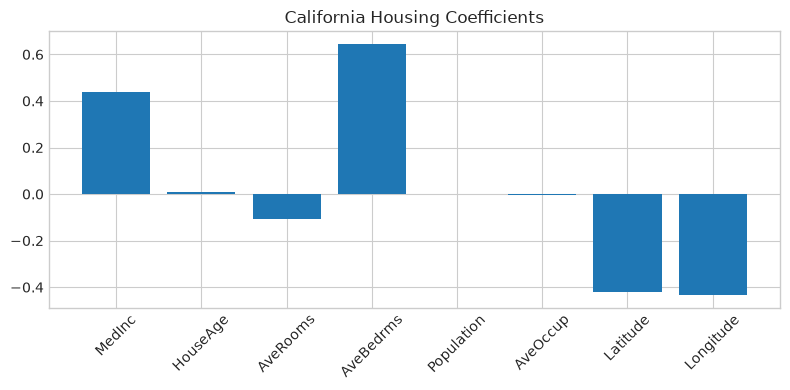

In [8]:
# Your Level 2 solution here
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X_h, y_h = pd.DataFrame(housing.data, columns=housing.feature_names), housing.target
model_h = LinearRegression()
model_h.fit(X_h, y_h)
plt.figure(figsize=(8, 4))
plt.bar(housing.feature_names, model_h.coef_)
plt.xticks(rotation=45)
plt.title('California Housing Coefficients')
plt.tight_layout()
plt.show()

## 8. Coding Challenge

Implement linear regression from scratch using the normal equation. Compare coefficients with sklearn.

In [9]:
def linear_regression_normal_equation(X, y):
    X_aug = np.c_[np.ones(X.shape[0]), X]
    beta = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y
    return beta[0], beta[1:]  # intercept, coefficients

int_scratch, coef_scratch = linear_regression_normal_equation(X_train.values, y_train)
print(f"Intercept - scratch: {int_scratch:.2f}, sklearn: {model.intercept_:.2f}")
print(f"Coef match: {np.allclose(coef_scratch, model.coef_, atol=1e-8)}")

Intercept - scratch: 151.35, sklearn: 151.35
Coef match: True


## Summary

- Linear regression predicts a continuous target as weighted sum of features
- OLS finds optimal coefficients by minimizing MSE
- R² measures how much variance the model explains
- Gradient descent iteratively finds coefficients for large datasets
- Always check residuals and assumptions